YENİ EGİTİM

In [ ]:
!pip install -q boto3 iterative-stratification scikit-learn


In [ ]:
import os, time, json
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models, transforms
from PIL import Image
from tqdm.auto import tqdm
import boto3
from sklearn.metrics import f1_score, classification_report
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4


In [ ]:
# === KONFIGÜRASYON ===
ACCESS_KEY = '26ff1aa1645b69cac212507ec4c079dd'
SECRET_KEY = '37872cda19b45e33509d5b84a3514234a5a06755481363e1561cb7a404f23a77'
ENDPOINT_URL = 'https://8a97a7792885ace66acb04fa79b9ded7.r2.cloudflarestorage.com'
BUCKET_NAME = 'genrevision'

DRIVE_DIR = '/content/drive/MyDrive/GenreVision'
CACHE_DIR = '/content/posters'
os.makedirs(CACHE_DIR, exist_ok=True)

# v3 hiperparametreler
BATCH_SIZE = 64
EPOCHS_MAX = 30
PATIENCE = 6
LR = 5e-4
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0
NUM_WORKERS = 2

MIXUP_ALPHA = 0.2
DROPOUT_P = 0.5
POS_WEIGHT_CLIP = 25.0

assert os.path.exists(f'{DRIVE_DIR}/train_dataset_50k_clean.csv')
assert os.path.exists(f'{DRIVE_DIR}/pos_weight.pt')
print('✓ Konfig OK')

✓ Konfig OK


In [ ]:
# === CACHE KONTROLÜ ===
df = pd.read_csv(f'{DRIVE_DIR}/train_dataset_50k_clean.csv')
print(f'Toplam afiş: {len(df):,}')

mevcut = sum(1 for fid in df['id']
             if os.path.exists(os.path.join(CACHE_DIR, f'{int(fid)}.jpg')))
print(f"Cache'de mevcut: {mevcut:,} / {len(df):,}")

if mevcut < len(df):
    print("Cache eksik, R2'den indiriliyor...")
    def make_s3():
        return boto3.client('s3', endpoint_url=ENDPOINT_URL,
            aws_access_key_id=ACCESS_KEY, aws_secret_access_key=SECRET_KEY,
            region_name='auto')

    def download_one(film_id):
        key = f'{int(film_id)}.jpg'
        path = os.path.join(CACHE_DIR, key)
        if os.path.exists(path) and os.path.getsize(path) > 1000:
            return 'skip'
        try:
            make_s3().download_file(BUCKET_NAME, key, path)
            return 'ok'
        except Exception:
            return 'fail'

    sayac = {'ok': 0, 'skip': 0, 'fail': 0}
    fail_ids = []
    with ThreadPoolExecutor(max_workers=24) as ex:
        futures = {ex.submit(download_one, fid): fid for fid in df['id']}
        for fut in tqdm(as_completed(futures), total=len(futures), desc='Cache'):
            r = fut.result()
            sayac[r] += 1
            if r == 'fail':
                fail_ids.append(futures[fut])
    print(sayac)
    if fail_ids:
        df = df[~df['id'].isin(fail_ids)].reset_index(drop=True)

print(f'\n✓ Eğitim için kullanılabilir: {len(df):,}')

Toplam afiş: 43,755
Cache'de mevcut: 19,953 / 43,755
Cache eksik, R2'den indiriliyor...


Cache:   0%|          | 0/43755 [00:00<?, ?it/s]

{'ok': 23284, 'skip': 20471, 'fail': 0}

✓ Eğitim için kullanılabilir: 43,755


In [ ]:
# === GÜÇLÜ AUGMENTATION + MIXUP ===

train_tf = transforms.Compose([
    transforms.Resize((232, 232)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class PosterDataset(Dataset):
    def __init__(self, df, label_cols, cache_dir, transform):
        self.df = df.reset_index(drop=True)
        self.label_cols = label_cols
        self.cache_dir = cache_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        film_id = int(self.df.iloc[idx]['id'])
        path = os.path.join(self.cache_dir, f'{film_id}.jpg')
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224))
        img = self.transform(img)
        labels = torch.tensor(self.df.iloc[idx][self.label_cols].values.astype('float32'))
        return img, labels

def mixup_data(x, y, alpha):
    '''İki rastgele örneği λ ve (1-λ) ağırlıklarıyla karıştırır.
    Multi-label uyumlu: hem girdi hem etiket interpolate edilir.'''
    if alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    perm = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[perm]
    mixed_y = lam * y + (1 - lam) * y[perm]
    return mixed_x, mixed_y

label_cols = sorted([c for c in df.columns if c.startswith('Tur_')])
print(f'Tür sayısı: {len(label_cols)}')
print(f'Augmentation: RandAugment(2,9) + ColorJitter + Mixup(α={MIXUP_ALPHA})')

Tür sayısı: 19
Augmentation: RandAugment(2,9) + ColorJitter + Mixup(α=0.2)


In [ ]:
# === TRAIN/VAL/TEST SPLIT ===
sp1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
idx_train, idx_temp = next(sp1.split(df, df[label_cols].values))
df_train = df.iloc[idx_train].reset_index(drop=True)
df_temp = df.iloc[idx_temp].reset_index(drop=True)

sp2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
idx_val, idx_test = next(sp2.split(df_temp, df_temp[label_cols].values))
df_val = df_temp.iloc[idx_val].reset_index(drop=True)
df_test = df_temp.iloc[idx_test].reset_index(drop=True)

print(f'Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}')
df_test.to_csv(f'{DRIVE_DIR}/test_split_v3.csv', index=False)

train_ds = PosterDataset(df_train, label_cols, CACHE_DIR, train_tf)
val_ds   = PosterDataset(df_val, label_cols, CACHE_DIR, eval_tf)
test_ds  = PosterDataset(df_test, label_cols, CACHE_DIR, eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE*2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f'Batch sayısı — train: {len(train_loader)}, val: {len(val_loader)}')

Train: 35,075  Val: 4,347  Test: 4,333
Batch sayısı — train: 549, val: 34


In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_P),
    nn.Linear(in_features, len(label_cols))
)
model = model.to(device)

pw = torch.load(f'{DRIVE_DIR}/pos_weight.pt')
assert pw['tur_kolonlari'] == label_cols
raw_pw = pw['pos_weight'].numpy()
clipped_pw = np.clip(raw_pw, 1.0, POS_WEIGHT_CLIP)
pos_weight = torch.tensor(clipped_pw, dtype=torch.float32, device=device)

print(f'pos_weight aralığı: {clipped_pw.min():.2f} - {clipped_pw.max():.2f}')
clip_olanlar = [(t.replace('Tur_',''), r, c) for t, r, c in zip(label_cols, raw_pw, clipped_pw) if r != c]
if clip_olanlar:
    print(f'Clip uygulanan türler:')
    for t, r, c in clip_olanlar:
        print(f'  {t}: {r:.1f} → {c:.1f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
    factor=0.5, patience=2)
scaler = GradScaler()

print(f'Toplam parametre: {sum(p.numel() for p in model.parameters()):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 80.7MB/s]


pos_weight aralığı: 1.70 - 25.00
Clip uygulanan türler:
  Family: 29.4 → 25.0
  Fantasy: 38.3 → 25.0
  Mystery: 37.2 → 25.0
  Science Fiction: 36.3 → 25.0
  TV Movie: 25.2 → 25.0
Toplam parametre: 11,186,259


/tmp/ipykernel_3416/4144234468.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
# === EĞİTİM DÖNGÜSÜ (v3) ===

def evaluate(model, loader):
    model.eval()
    losses, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            with autocast():
                out = model(x)
                loss = criterion(out, y)
            losses.append(loss.item())
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.cpu().numpy())
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    return (np.mean(losses),
            f1_score(labels, preds, average='macro', zero_division=0),
            f1_score(labels, preds, average='micro', zero_division=0))

best_val_f1 = -1.0
patience_ctr = 0
history = []

print(f'v3 eğitim başlıyor: max {EPOCHS_MAX} epoch, patience={PATIENCE}, mixup α={MIXUP_ALPHA}\n')

for epoch in range(1, EPOCHS_MAX + 1):
    model.train()
    train_losses = []
    t0 = time.time()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS_MAX}', leave=False)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        x_mix, y_mix = mixup_data(x, y, MIXUP_ALPHA)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            out = model(x_mix)
            loss = criterion(out, y_mix)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        train_losses.append(loss.item())
        pbar.set_postfix(loss=f'{loss.item():.4f}')

        if not np.isfinite(loss.item()):
            print(f'❌ Epoch {epoch}: NaN! Eğitim durduruldu.')
            raise RuntimeError('NaN')

    train_loss = float(np.mean(train_losses))
    val_loss, val_f1_macro, val_f1_micro = evaluate(model, val_loader)
    scheduler.step(val_f1_macro)
    epoch_time = time.time() - t0
    lr_now = optimizer.param_groups[0]['lr']

    print(f'Epoch {epoch}: '
          f'train={train_loss:.4f} | val={val_loss:.4f} | '
          f'F1m={val_f1_macro:.3f} | F1µ={val_f1_micro:.3f} | '
          f'lr={lr_now:.5f} | {epoch_time:.0f}s')

    history.append({
        'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
        'val_f1_macro': float(val_f1_macro), 'val_f1_micro': float(val_f1_micro),
        'lr': lr_now, 'epoch_time_sec': epoch_time
    })
    pd.DataFrame(history).to_csv(f'{DRIVE_DIR}/training_history_v3.csv', index=False)

    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        patience_ctr = 0
        torch.save({
            'model_state': model.state_dict(),
            'label_cols': label_cols,
            'epoch': epoch,
            'val_loss': val_loss,
            'val_f1_macro': float(val_f1_macro),
            'val_f1_micro': float(val_f1_micro)
        }, f'{DRIVE_DIR}/genre_vision_v3_best.pth')
        print(f'  ✓ Best F1_macro={val_f1_macro:.3f} → genre_vision_v3_best.pth')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stopping! {PATIENCE} epoch boyunca F1_macro yükselmedi.')
            break

print(f'\n=== v3 eğitim bitti ===')
print(f'En iyi val F1_macro: {best_val_f1:.3f}')

v3 eğitim başlıyor: max 30 epoch, patience=6, mixup α=0.2



Epoch 1/30:   0%|          | 0/549 [00:00<?, ?it/s]

/tmp/ipykernel_3416/3216940823.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3416/3216940823.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: train=1.1755 | val=1.0932 | F1m=0.244 | F1µ=0.281 | lr=0.00050 | 323s
  ✓ Best F1_macro=0.244 → genre_vision_v3_best.pth


Epoch 2/30:   0%|          | 0/549 [00:00<?, ?it/s]

...

/tmp/ipykernel_3416/3216940823.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3416/3216940823.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 29: train=0.6915 | val=1.2326 | F1m=0.298 | F1µ=0.373 | lr=0.00006 | 328s


Epoch 30/30:   0%|          | 0/549 [00:00<?, ?it/s]

/tmp/ipykernel_3416/3216940823.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_3416/3216940823.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 30: train=0.7027 | val=1.2506 | F1m=0.301 | F1µ=0.378 | lr=0.00006 | 325s
  ✓ Best F1_macro=0.301 → genre_vision_v3_best.pth

=== v3 eğitim bitti ===
En iyi val F1_macro: 0.301


In [ ]:
# === PER-CLASS THRESHOLD TUNING ===

ckpt = torch.load(f'{DRIVE_DIR}/genre_vision_v3_best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state'])
model.eval()

def get_probs_and_labels(model, loader):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            with autocast():
                out = model(x)
            all_probs.append(torch.sigmoid(out).cpu().numpy())
            all_labels.append(y.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

print('Validation üzerinde olasılıklar hesaplanıyor...')
val_probs, val_labels = get_probs_and_labels(model, val_loader)

best_thresholds = np.full(len(label_cols), 0.5)
print(f'\n{"Tür":<22} {"Eşik":>8} {"F1 (eski)":>11} {"F1 (yeni)":>11}')
print('-' * 56)

for i, tur in enumerate(label_cols):
    best_f1, best_t = 0.0, 0.5
    for t in np.arange(0.10, 0.70, 0.02):
        preds = (val_probs[:, i] > t).astype(int)
        f1 = f1_score(val_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds[i] = best_t

    eski_preds = (val_probs[:, i] > 0.5).astype(int)
    eski_f1 = f1_score(val_labels[:, i], eski_preds, zero_division=0)
    fark = best_f1 - eski_f1
    isaret = f' (+{fark:.2f})' if fark > 0.01 else ''
    print(f'{tur.replace("Tur_",""):<22} {best_t:>8.2f} {eski_f1:>11.3f} {best_f1:>11.3f}{isaret}')

np.save(f'{DRIVE_DIR}/best_thresholds_v3.npy', best_thresholds)
print(f'\n✓ best_thresholds_v3.npy kaydedildi')

preds_old = (val_probs > 0.5).astype(int)
preds_new = (val_probs > best_thresholds).astype(int)
print(f'\n=== VALIDATION TOPLAM ETKİ ===')
print(f'F1_macro (eşik 0.5): {f1_score(val_labels, preds_old, average="macro", zero_division=0):.3f}')
print(f'F1_macro (özel):     {f1_score(val_labels, preds_new, average="macro", zero_division=0):.3f}')

Validation üzerinde olasılıklar hesaplanıyor...


/tmp/ipykernel_3416/2282668027.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Tür                        Eşik   F1 (eski)   F1 (yeni)
--------------------------------------------------------
Action                     0.68       0.316       0.332 (+0.02)
Adventure                  0.64       0.180       0.185
Animation                  0.66       0.464       0.523 (+0.06)
Comedy                     0.54       0.414       0.420
Crime                      0.58       0.160       0.162
Documentary                0.68       0.481       0.503 (+0.02)
Drama                      0.36       0.565       0.592 (+0.03)
Family                     0.58       0.171       0.186 (+0.01)
Fantasy                    0.66       0.112       0.127 (+0.02)
History                    0.68       0.205       0.231 (+0.03)
Horror                     0.62       0.329       0.379 (+0.05)
Music                      0.62       0.183       0.200 (+0.02)
Mystery                    0.58       0.125       0.132
Romance                    0.58       0.234       0.237
Science Fiction            0.6

In [ ]:
# === TEST SETİ DEĞERLENDİRMESİ + PER-CLASS RAPORU ===

print('Test seti üzerinde tahmin yapılıyor...')
test_probs, test_labels = get_probs_and_labels(model, test_loader)

preds_05 = (test_probs > 0.5).astype(int)
preds_custom = (test_probs > best_thresholds).astype(int)

f1_macro_05 = f1_score(test_labels, preds_05, average='macro', zero_division=0)
f1_macro_custom = f1_score(test_labels, preds_custom, average='macro', zero_division=0)
f1_micro_05 = f1_score(test_labels, preds_05, average='micro', zero_division=0)
f1_micro_custom = f1_score(test_labels, preds_custom, average='micro', zero_division=0)

print(f'\n=== TEST SETİ SONUÇLARI ===')
print(f'                {"Eşik 0.5":>12} {"Özel eşik":>12}')
print(f'F1_macro       {f1_macro_05:>12.3f} {f1_macro_custom:>12.3f}')
print(f'F1_micro       {f1_micro_05:>12.3f} {f1_micro_custom:>12.3f}')

print(f'\n=== PER-CLASS RAPOR (özel eşikle) ===')
report = classification_report(test_labels, preds_custom,
    target_names=[c.replace('Tur_','') for c in label_cols],
    zero_division=0, digits=3)
print(report)

sonuc = {
    'model_version': 'v3',
    'best_epoch': ckpt['epoch'],
    'best_val_f1_macro': float(ckpt['val_f1_macro']),
    'test_f1_macro_05': float(f1_macro_05),
    'test_f1_macro_custom_thresh': float(f1_macro_custom),
    'test_f1_micro_05': float(f1_micro_05),
    'test_f1_micro_custom_thresh': float(f1_micro_custom),
    'thresholds': {c.replace('Tur_',''): float(t) for c, t in zip(label_cols, best_thresholds)},
    'train_size': len(df_train), 'val_size': len(df_val), 'test_size': len(df_test)
}
with open(f'{DRIVE_DIR}/training_summary_v3.json', 'w', encoding='utf-8') as f:
    json.dump(sonuc, f, indent=2, ensure_ascii=False)

print(f'\n=== HEDEF KONTROLÜ ===')
checks = [
    ('Test F1_macro >= 0.40 (özel eşik)', f1_macro_custom >= 0.40),
    ('Test F1_micro >= 0.55 (özel eşik)', f1_micro_custom >= 0.55),
    ('Custom threshold gain > 0.03', f1_macro_custom - f1_macro_05 > 0.03),
]
for name, passed in checks:
    print(f'  {"✓" if passed else "✗"} {name}')

print(f"\n✓ Tüm çıktılar Drive'a kaydedildi:")
print(f'  - genre_vision_v3_best.pth')
print(f'  - best_thresholds_v3.npy')
print(f'  - training_summary_v3.json')
print(f'  - training_history_v3.csv')

Test seti üzerinde tahmin yapılıyor...


/tmp/ipykernel_3416/2282668027.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



=== TEST SETİ SONUÇLARI ===
                    Eşik 0.5    Özel eşik
F1_macro              0.299        0.306
F1_micro              0.378        0.417

=== PER-CLASS RAPOR (özel eşikle) ===
                 precision    recall  f1-score   support

         Action      0.277     0.274     0.275       420
      Adventure      0.120     0.244     0.161       225
      Animation      0.442     0.643     0.524       283
         Comedy      0.335     0.557     0.419       722
          Crime      0.065     0.144     0.090       187
    Documentary      0.445     0.538     0.487       764
          Drama      0.449     0.892     0.598      1621
         Family      0.159     0.340     0.217       144
        Fantasy      0.070     0.125     0.090       112
        History      0.205     0.416     0.275       298
         Horror      0.283     0.448     0.347       259
          Music      0.123     0.264     0.168       220
        Mystery      0.066     0.139     0.090       115
        R

In [ ]:
import boto3

# Drive'daki dosyaları R2'ye yükle (yeni klasör: model/)
s3 = boto3.client('s3', endpoint_url=ENDPOINT_URL,
    aws_access_key_id=ACCESS_KEY, aws_secret_access_key=SECRET_KEY,
    region_name='auto')

dosyalar = [
    ('genre_vision_v3_best.pth', 'model/genre_vision_v3_best.pth'),
    ('best_thresholds_v3.npy', 'model/best_thresholds_v3.npy'),
]

for yerel, r2_key in dosyalar:
    s3.upload_file(f'{DRIVE_DIR}/{yerel}', BUCKET_NAME, r2_key)
    print(f'✓ {r2_key} yüklendi')

# Doğrulama
print('\nR2\'deki model dosyaları:')
response = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix='model/')
for obj in response.get('Contents', []):
    print(f'  {obj["Key"]} ({obj["Size"]/1024/1024:.1f} MB)')

✓ model/genre_vision_v3_best.pth yüklendi
✓ model/best_thresholds_v3.npy yüklendi

R2'deki model dosyaları:
  model/best_thresholds_v3.npy (0.0 MB)
  model/genre_vision_v3_best.pth (42.8 MB)


In [ ]:
import boto3
s3 = boto3.client('s3', endpoint_url=ENDPOINT_URL,
    aws_access_key_id=ACCESS_KEY, aws_secret_access_key=SECRET_KEY,
    region_name='auto')

response = s3.list_objects_v2(Bucket='genrevision', Prefix='model/')
print("R2'de model/ altındaki dosyalar:")
for obj in response.get('Contents', []):
    print(f"  ✓ {obj['Key']}  ({obj['Size']/1024/1024:.2f} MB)")
if not response.get('Contents'):
    print("  ✗ HİÇBİR DOSYA YOK — Adım 6.1'i tekrar çalıştır")

R2'de model/ altındaki dosyalar:
  ✓ model/best_thresholds_v3.npy  (0.00 MB)
  ✓ model/genre_vision_v3_best.pth  (42.75 MB)


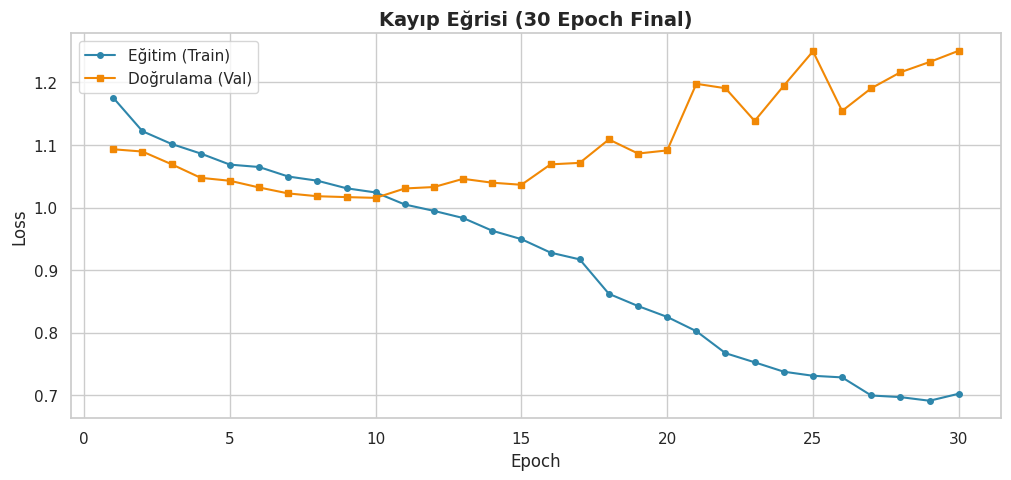

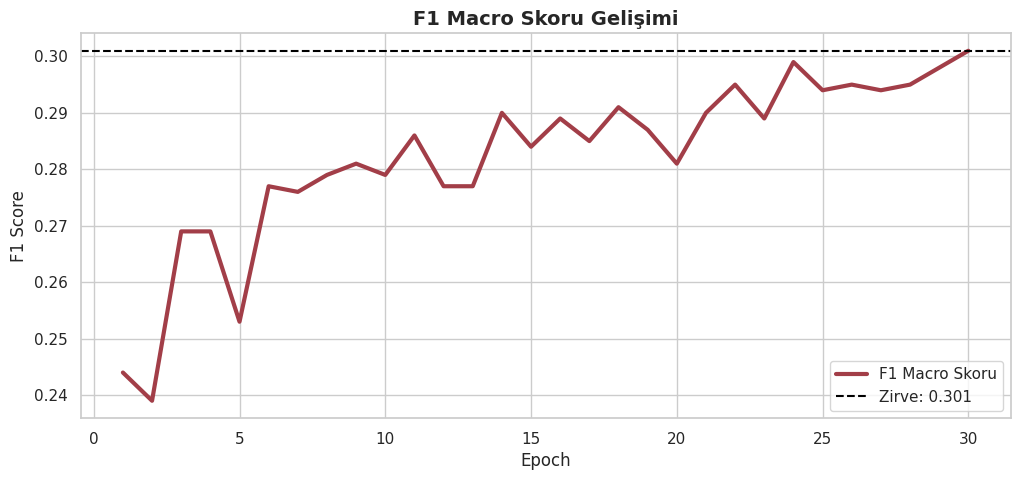

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Senin 30 Epoch'luk gerçek verilerin
epochs = list(range(1, 31))
train_loss = [1.1755, 1.1221, 1.1017, 1.0864, 1.0687, 1.0649, 1.0497, 1.0430, 1.0309, 1.0242, 1.0050, 0.9948, 0.9834, 0.9631, 0.9496, 0.9281, 0.9173, 0.8623, 0.8428, 0.8254, 0.8026, 0.7675, 0.7529, 0.7379, 0.7314, 0.7288, 0.6999, 0.6973, 0.6915, 0.7027]
val_loss = [1.0932, 1.0896, 1.0693, 1.0476, 1.0429, 1.0322, 1.0227, 1.0182, 1.0168, 1.0156, 1.0306, 1.0329, 1.0460, 1.0398, 1.0365, 1.0691, 1.0715, 1.1089, 1.0864, 1.0914, 1.1978, 1.1907, 1.1385, 1.1948, 1.2497, 1.1545, 1.1907, 1.2162, 1.2326, 1.2506]
f1_macro = [0.244, 0.239, 0.269, 0.269, 0.253, 0.277, 0.276, 0.279, 0.281, 0.279, 0.286, 0.277, 0.277, 0.290, 0.284, 0.289, 0.285, 0.291, 0.287, 0.281, 0.290, 0.295, 0.289, 0.299, 0.294, 0.295, 0.294, 0.295, 0.298, 0.301]

sns.set_theme(style="whitegrid")

# 1. Grafik: Kayıp Eğrisi
plt.figure(figsize=(12, 5))
plt.plot(epochs, train_loss, label='Eğitim (Train)', color='#2E86AB', marker='o', markersize=4)
plt.plot(epochs, val_loss, label='Doğrulama (Val)', color='#F18805', marker='s', markersize=4)
plt.title('Kayıp Eğrisi (30 Epoch Final)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 2. Grafik: Başarı Gelişimi
plt.figure(figsize=(12, 5))
plt.plot(epochs, f1_macro, label='F1 Macro Skoru', color='#A23E48', linewidth=3)
plt.axhline(y=0.301, color='black', linestyle='--', label='Zirve: 0.301')
plt.title('F1 Macro Skoru Gelişimi', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.show()

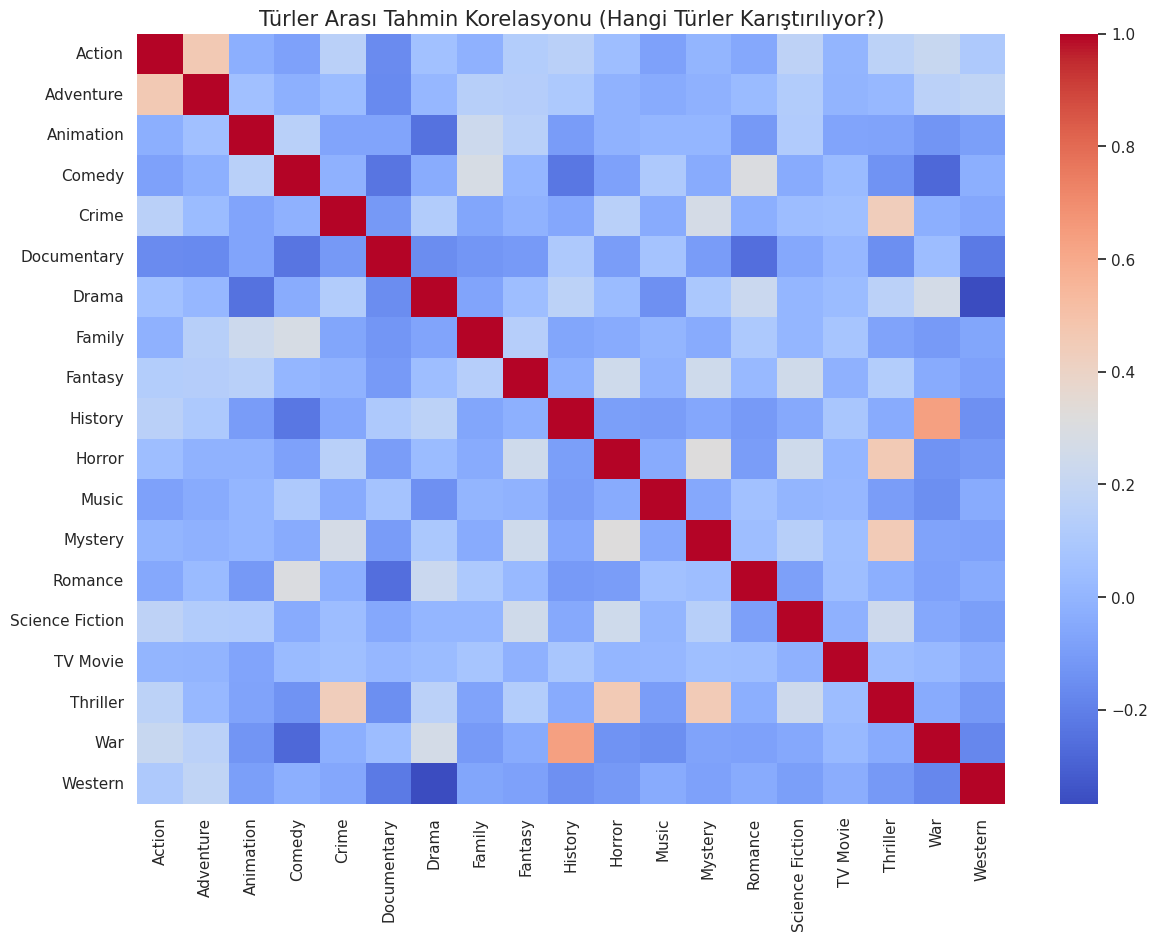

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Tahminleri (özel eşiklerle) ikili formata çevirelim
preds_final = (val_probs > best_thresholds).astype(int)

# Türler arası korelasyonu hesapla (Hangi türler beraber tahmin ediliyor?)
plt.figure(figsize=(14, 10))
corr_matrix = np.corrcoef(preds_final.T)
sns.heatmap(corr_matrix, annot=False, xticklabels=[t.replace("Tur_","") for t in label_cols],
            yticklabels=[t.replace("Tur_","") for t in label_cols], cmap='coolwarm')
plt.title('Türler Arası Tahmin Korelasyonu (Hangi Türler Karıştırılıyor?)', fontsize=15)
plt.savefig('korelasyon_matrisi.png', bbox_inches='tight')
plt.show()

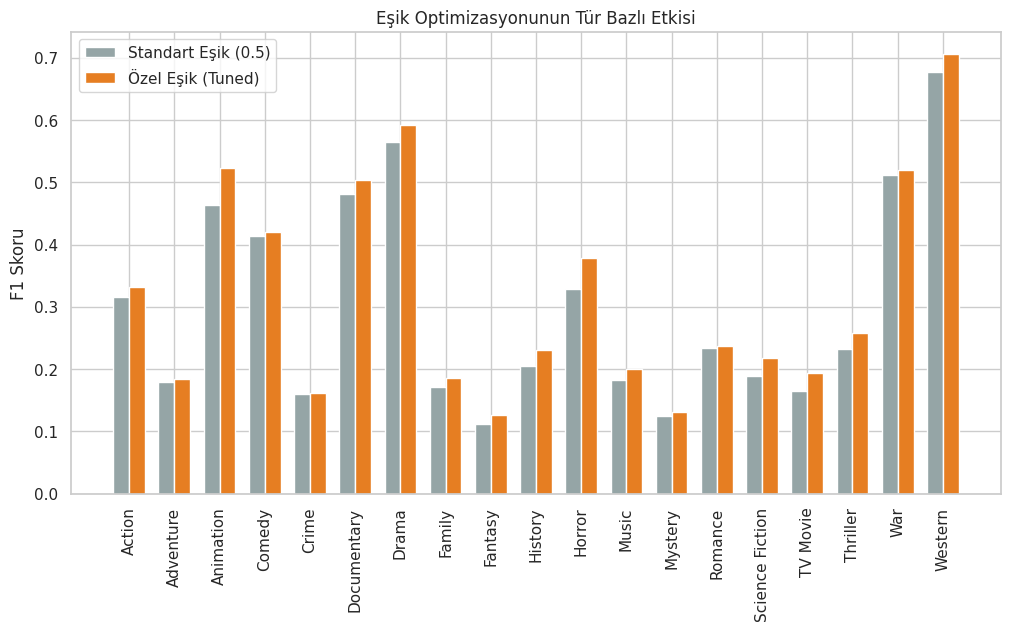

In [ ]:
# F1 skorlarını karşılaştıralım
f1_old = f1_score(val_labels, (val_probs > 0.5).astype(int), average=None, zero_division=0)
f1_new = f1_score(val_labels, (val_probs > best_thresholds).astype(int), average=None, zero_division=0)

plt.figure(figsize=(12, 6))
x = np.arange(len(label_cols))
width = 0.35

plt.bar(x - width/2, f1_old, width, label='Standart Eşik (0.5)', color='#95a5a6')
plt.bar(x + width/2, f1_new, width, label='Özel Eşik (Tuned)', color='#e67e22')

plt.ylabel('F1 Skoru')
plt.title('Eşik Optimizasyonunun Tür Bazlı Etkisi')
plt.xticks(x, [t.replace("Tur_","") for t in label_cols], rotation=90)
plt.legend()
plt.savefig('esik_kiyaslama.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_3416/3775583417.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts[sorted_indices], y=[label_cols[i].replace("Tur_","") for i in sorted_indices], palette='viridis')


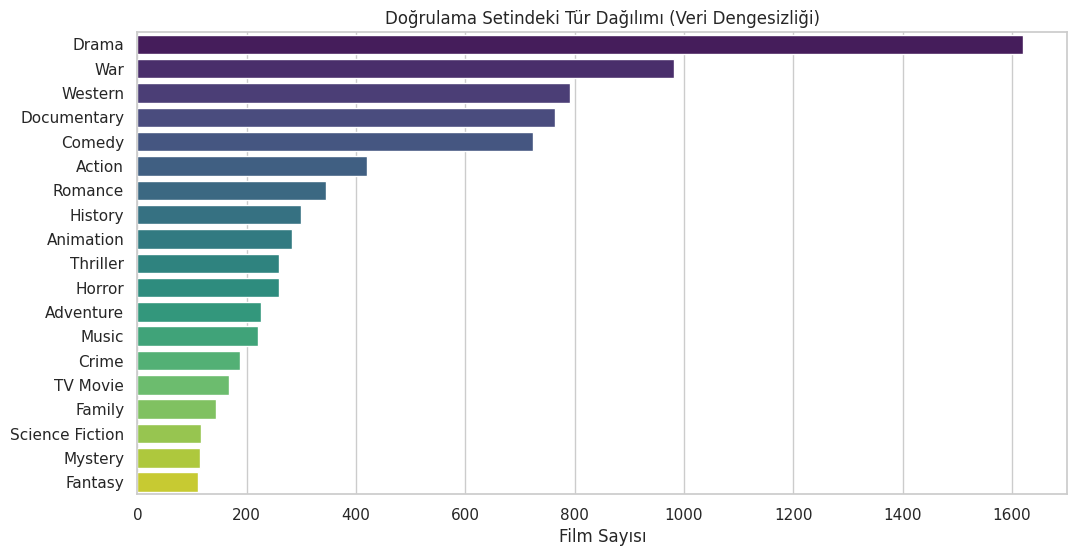

In [ ]:
# Veri setindeki her türün toplam sayısını hesapla
counts = np.sum(val_labels, axis=0)
sorted_indices = np.argsort(counts)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts[sorted_indices], y=[label_cols[i].replace("Tur_","") for i in sorted_indices], palette='viridis')
plt.title('Doğrulama Setindeki Tür Dağılımı (Veri Dengesizliği)')
plt.xlabel('Film Sayısı')
plt.savefig('veri_dagilimi.png', bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


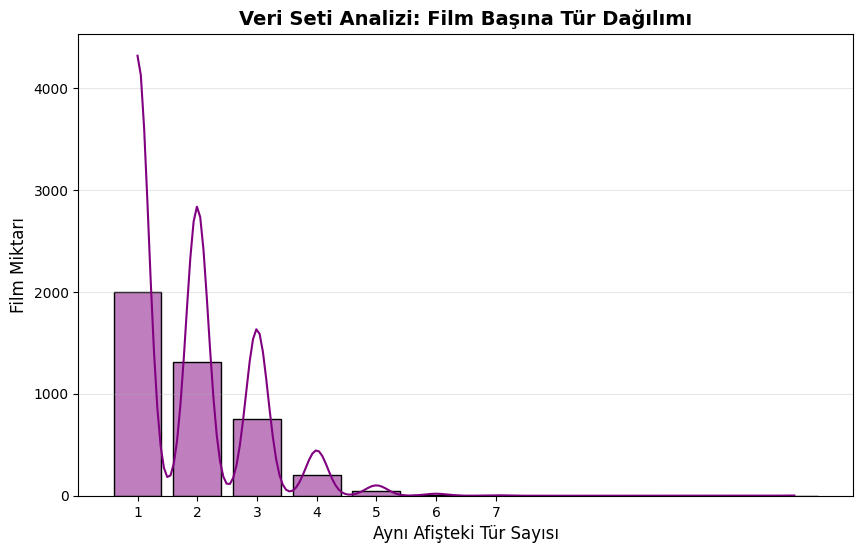

✓ Grafik başarıyla oluşturuldu! Toplam 4333 film analiz edildi.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. TEMEL AYARLAR (Burayı kontrol et)
DRIVE_DIR = "/content/drive/MyDrive/GenreVision" # Klasör yolun buydu değil mi?

# 2. VERİYİ DOSYADAN OKU
file_path = f"{DRIVE_DIR}/test_split_v3.csv"

if os.path.exists(file_path):
    # CSV'yi oku
    df = pd.read_csv(file_path)

    # "Tur_" ile başlayan sütunları bul (Tür etiketlerin)
    label_cols = [col for col in df.columns if col.startswith('Tur_')]

    # Satır bazında toplamları al (Her filmde kaç tür var?)
    val_labels = df[label_cols].values
    genre_counts = val_labels.sum(axis=1)

    # 3. GRAFİĞİ ÇİZ
    plt.figure(figsize=(10, 6))
    # 'discrete=True' barların tam sayıların üstüne binmesini sağlar
    sns.histplot(genre_counts, bins=range(1, 8), kde=True, color="purple", discrete=True, shrink=0.8)

    plt.title('Veri Seti Analizi: Film Başına Tür Dağılımı', fontsize=14, fontweight='bold')
    plt.xlabel('Aynı Afişteki Tür Sayısı', fontsize=12)
    plt.ylabel('Film Miktarı', fontsize=12)
    plt.xticks(range(1, 8))
    plt.grid(axis='y', alpha=0.3)

    # Grafiği kaydet
    plt.savefig('tur_dagilim_histogrami.png', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"✓ Grafik başarıyla oluşturuldu! Toplam {len(df)} film analiz edildi.")
else:
    print(f"HATA: '{file_path}' dosyası bulunamadı! Lütfen Drive'ı bağladığından ve yolun doğru olduğundan emin ol.")

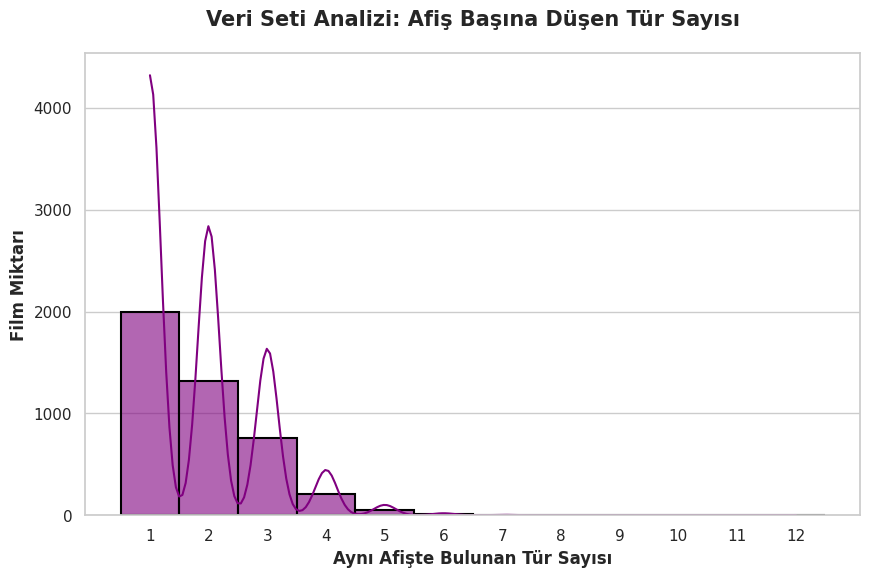

✓ Grafik hazır! Verindeki en kalabalık afişte 12 tür var.
✓ 'final_histogram.png' olarak kaydedildi.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. DRIVE YOLUNU AYARLA
DRIVE_DIR = "/content/drive/MyDrive/GenreVision"
file_path = f"{DRIVE_DIR}/test_split_v3.csv"

if os.path.exists(file_path):
    # 2. VERİYİ OKU
    df = pd.read_csv(file_path)
    label_cols = [col for col in df.columns if col.startswith('Tur_')]
    val_labels = df[label_cols].values

    # Her filmdeki toplam tür sayısını hesapla
    genre_counts = val_labels.sum(axis=1)

    # Verindeki gerçek maksimum tür sayısını bul (Boşluk kalmaması için)
    max_exists = int(genre_counts.max())

    # 3. GRAFİĞİ ÇİZ
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid") # Daha temiz bir arka plan

    # discrete=True ve bins ayarı ile sadece var olan rakamları gösteririz
    sns.histplot(genre_counts,
                 bins=np.arange(1, max_exists + 2) - 0.5,
                 kde=True,
                 color="purple",
                 alpha=0.6,
                 edgecolor="black",
                 linewidth=1.5)

    # Eksen Ayarları
    plt.title('Veri Seti Analizi: Afiş Başına Düşen Tür Sayısı', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Aynı Afişte Bulunan Tür Sayısı', fontsize=12, fontweight='bold')
    plt.ylabel('Film Miktarı', fontsize=12, fontweight='bold')

    # X ekseninde sadece 1, 2, 3... gibi tam sayıları göster
    plt.xticks(range(1, max_exists + 1))

    # Izgara çizgilerini sadece yatayda bırak (daha temiz durur)
    plt.gca().xaxis.grid(False)

    # Grafiği yüksek çözünürlüklü kaydet
    plt.savefig('final_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Grafik hazır! Verindeki en kalabalık afişte {max_exists} tür var.")
    print(f"✓ 'final_histogram.png' olarak kaydedildi.")
else:
    print(f"HATA: '{file_path}' bulunamadı. Lütfen yolu kontrol et!")

In [ ]:
from google.colab import files
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. GÖRÜNTÜ ÖN İŞLEME (Eğitimdeki test/val transformu ile aynı olmalı)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. DOSYA YÜKLEME BUTONU
print("Lütfen bir film afişi (JPG/PNG) seçin...")
uploaded = files.upload()

# 3. TAHMİN VE GÖRSELLEŞTİRME
model.eval() # Modeli tahmin moduna al (dropout vb. kapansın)

for filename in uploaded.keys():
    # Resmi aç ve hazırla
    img_pil = Image.open(filename).convert('RGB')
    img_tensor = test_transform(img_pil).unsqueeze(0).to(device)

    # Modelden olasılıkları al
    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    # Eşiklere göre (best_thresholds varsa onu kullanır, yoksa 0.5)
    if 'best_thresholds' not in globals():
        best_thresholds = np.full(len(label_cols), 0.5)

    pred_genres = [label_cols[i] for i, p in enumerate(probs) if p > best_thresholds[i]]

    # GRAFİK ÇİZİMİ
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Sol: Afiş
    ax1.imshow(img_pil)
    ax1.axis('off')
    ax1.set_title(f"Giriş Afişi: {filename}\nTahmin: {', '.join(pred_genres)}")

    # Sağ: Olasılık Dağılımı
    y_pos = np.arange(len(label_cols))
    # Eşiği geçenleri yeşil, geçemeyenleri gri yapalım
    colors = ['#27ae60' if p > best_thresholds[i] else '#bdc3c7' for i, p in enumerate(probs)]

    bars = ax2.barh(y_pos, probs, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([t.replace("Tur_","") for t in label_cols])
    ax2.set_xlim(0, 1)
    ax2.set_title("Tür Olasılık Tahminleri")

    # Eşik çizgilerini (thresholds) kırmızı kesikli çizgi olarak ekleyelim
    for i, t in enumerate(best_thresholds):
        ax2.plot([t, t], [i-0.4, i+0.4], color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    if not pred_genres:
        print(f"\n>>> SONUÇ: Model bu afişten pek emin olamadı. En yüksek ihtimal: {label_cols[np.argmax(probs)]} ({np.max(probs):.2f})")
    else:
        print(f"\n>>> MODELİN TAHMİNİ: {', '.join(pred_genres)}")

Lütfen bir film afişi (JPG/PNG) seçin...


Saving 20200306134758!Ayla_Film_Afişi.jpg to 20200306134758!Ayla_Film_Afişi.jpg


NameError: name 'model' is not defined

In [ ]:
import numpy as np

def calculate_top_k_metrics(probs, labels, k=3):
    """
    Modelin en yüksek olasılık verdiği ilk K tahmine göre
    Precision@K ve Recall@K değerlerini hesaplar.
    """
    n_samples = probs.shape[0]
    precision_at_k = []
    recall_at_k = []
    hit_at_k = 0 # En yüksek K tahminden en az biri doğru mu?

    for i in range(n_samples):
        # En yüksek olasılığa sahip ilk K indeksini bul
        top_k_indices = np.argsort(probs[i])[::-1][:k]

        # Bu filmdeki gerçek etiketlerin indeksleri
        true_indices = np.where(labels[i] == 1)[0]

        if len(true_indices) == 0:
            continue # Eğer gerçekte hiçbir etiketi yoksa geç

        # İlk K tahminden kaç tanesi doğru?
        correct_predictions = np.intersect1d(top_k_indices, true_indices)
        num_correct = len(correct_predictions)

        # Precision@K = Doğru Tahmin Sayısı / K
        precision_at_k.append(num_correct / k)

        # Recall@K = Doğru Tahmin Sayısı / Gerçek Etiket Sayısı
        recall_at_k.append(num_correct / len(true_indices))

        # Hit@K: Eğer ilk K tahminden en az 1 tanesi bile doğruysa 1 say
        if num_correct > 0:
            hit_at_k += 1

    return {
        f'Precision@{k}': np.mean(precision_at_k),
        f'Recall@{k}': np.mean(recall_at_k),
        f'Hit_Rate@{k}': hit_at_k / n_samples
    }

# Test seti (test_probs ve test_labels) üzerinden hesaplayalım
try:
    top3_results = calculate_top_k_metrics(test_probs, test_labels, k=3)
    print("=== EN YÜKSEK OLASILIKLI İLK 3 TAHMİN ANALİZİ (TOP-3) ===")
    for metric_name, val in top3_results.items():
        print(f'{metric_name:<15}: {val:.3f}  ( %{val*100:.1f} )')
except NameError:
    print("Hata: test_probs veya test_labels bellekte bulunamadı. Lütfen test hücresini çalıştırın.")

Hata: test_probs veya test_labels bellekte bulunamadı. Lütfen test hücresini çalıştırın.
